# Gold Miners Equity Alpha

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm

import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

# Getting Data

In [2]:
alpha_path = os.path.join(os.getcwd(), "data", "GoldMinersAlpha.parquet")
df_alpha   = (pd.read_parquet(
    path = alpha_path, engine = "pyarrow").
    reset_index().
    dropna())

In [3]:
path  = os.path.join(os.getcwd(), "data", "commod_px.parquet")
df_gc = (pd.read_parquet(
    path = path, engine = "pyarrow").
    query("security == 'GC1 Comdty'").
    assign(date = lambda x: pd.to_datetime(x.date).dt.date).
    set_index("date")
    [["PX_LAST"]].
    sort_index().
    pct_change().
    rename(columns = {"PX_LAST": "gc_rtn"}))

# Single exogenous variable regression

In [4]:
def _get_resid(df: pd.DataFrame, q: int = 10) -> pd.DataFrame: 
    
    df_tmp = df.dropna().sort_index()
    df_out = (sm.OLS(
        endog = df_tmp.gc_rtn,
        exog  = sm.add_constant(df_tmp.alpha)).
        fit().
        resid.
        to_frame(name = "resid").
        assign(
            lag_resid = lambda x: x.resid.shift(),
            decile    = lambda x: pd.qcut(x = x.resid, q = q, labels = [i + 1 for i in range(q)]).shift()).
        merge(right = df, how = "inner", on = ["date"]))
    
    return df_out

df_ols = (df_gc.merge(
    right = df_alpha, how = "inner", on = ["date"]).
    set_index("date").
    groupby("group_var").
    apply(_get_resid, include_groups = False).
    reset_index().
    assign(signal_rtn = lambda x: -np.sign(x.lag_resid) * x.gc_rtn))

In [5]:
df_ols_rsk = (df_ols.pivot(
    index = "date", columns = "group_var", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.2, np.nan, x)).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(
        ticker = lambda x: x.group_var.str.split(" ").str[0],
        group  = lambda x: x.group_var.str.split(" ").str[1]).
    dropna())

Text(0.5, 0.98, 'Cumulative Returns for Trading Residuals of Regression using 10% Volatility Targeting\nFrom 1993-03-31 to 2026-01-12')

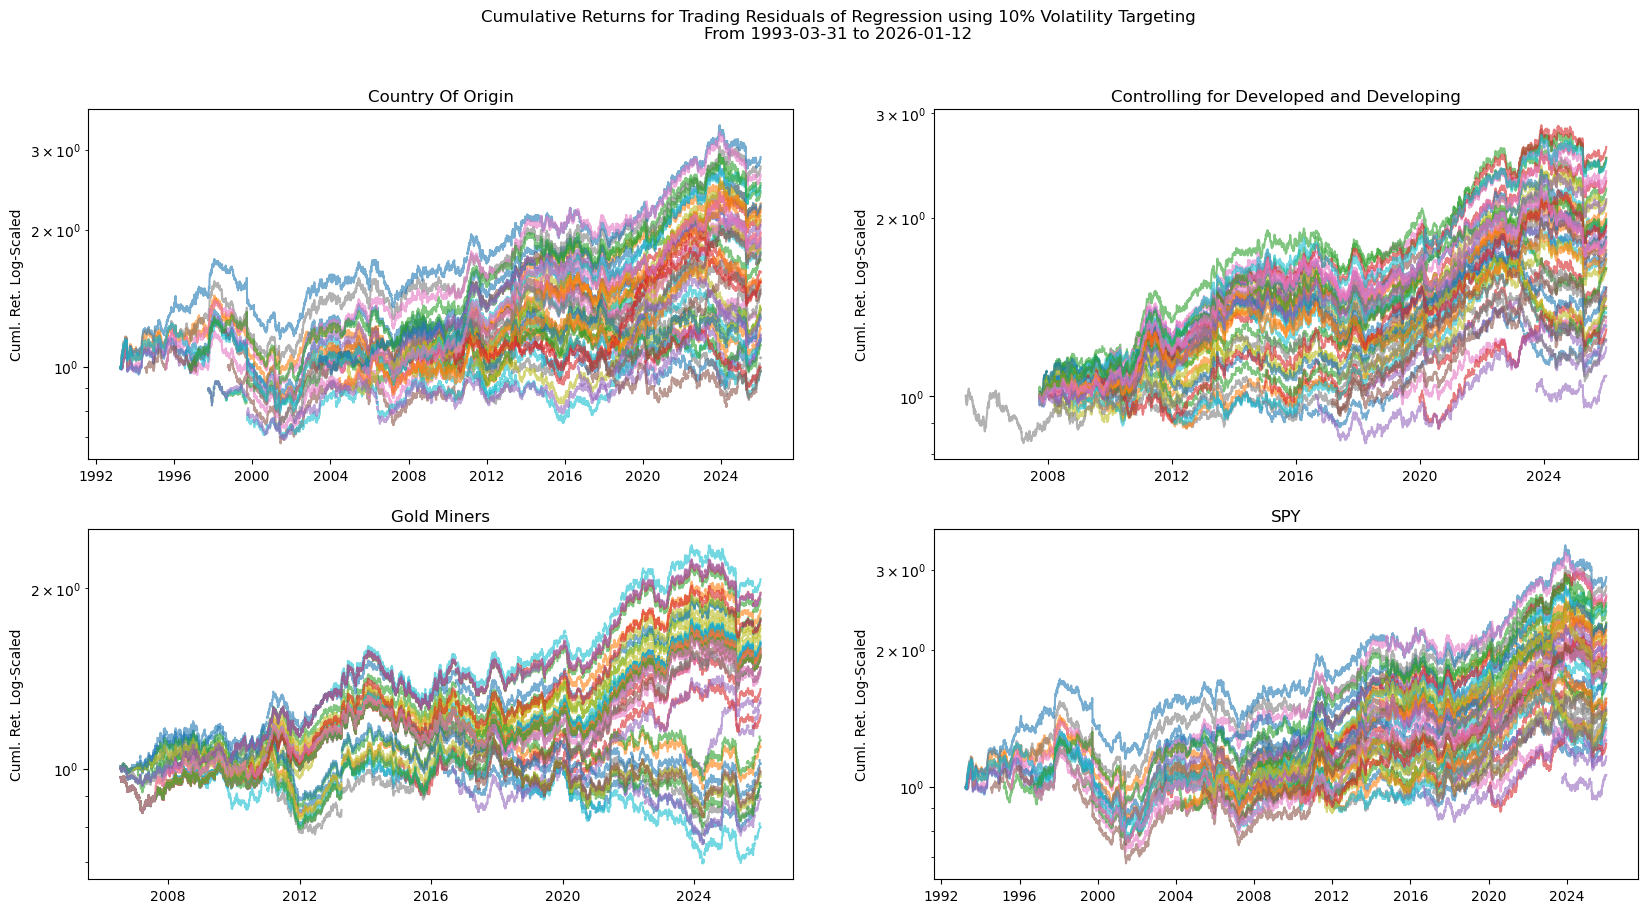

In [6]:
groups    = df_ols.group.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(groups) // 2, nrows = len(groups) // 2, figsize = (20,10))

renamer = {
    "country"           : "Country Of Origin",
    "country_type_group": "Controlling for Developed and Developing",
    "gdx"               : "Gold Miners",
    "spy"               : "SPY"}

for group, ax in zip(groups, axes.flatten()): 
    
    (df_ols_rsk.query(
        "group == @group").
        pivot(index = "date", columns = "ticker", values = "rtn").
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True, 
            alpha  = 0.6,
            legend = False,
            ax     = ax,
            title  = renamer[group],
            xlabel = "",
            ylabel = "Cuml. Ret. Log-Scaled"))

fig.suptitle("Cumulative Returns for Trading Residuals of Regression using 10% Volatility Targeting\nFrom {} to {}".format(
    df_ols_rsk.date.min(),
    df_ols_rsk.date.max()))

In [7]:
df_port = (df_ols_rsk[
    ["date", "group", "rtn"]].
    groupby(["date", "group"]).
    agg("mean").
    reset_index())

replacer = {
    "country": "Origin",
    "country_type_group": "Developed/ing",
    "gdx"               : "Gold Miner",
    "spy"               : "SPY"}

In [8]:
df_corr = (df_port.replace(
    replacer).
    pivot(index = "date", columns = "group", values = "rtn").
    corr())

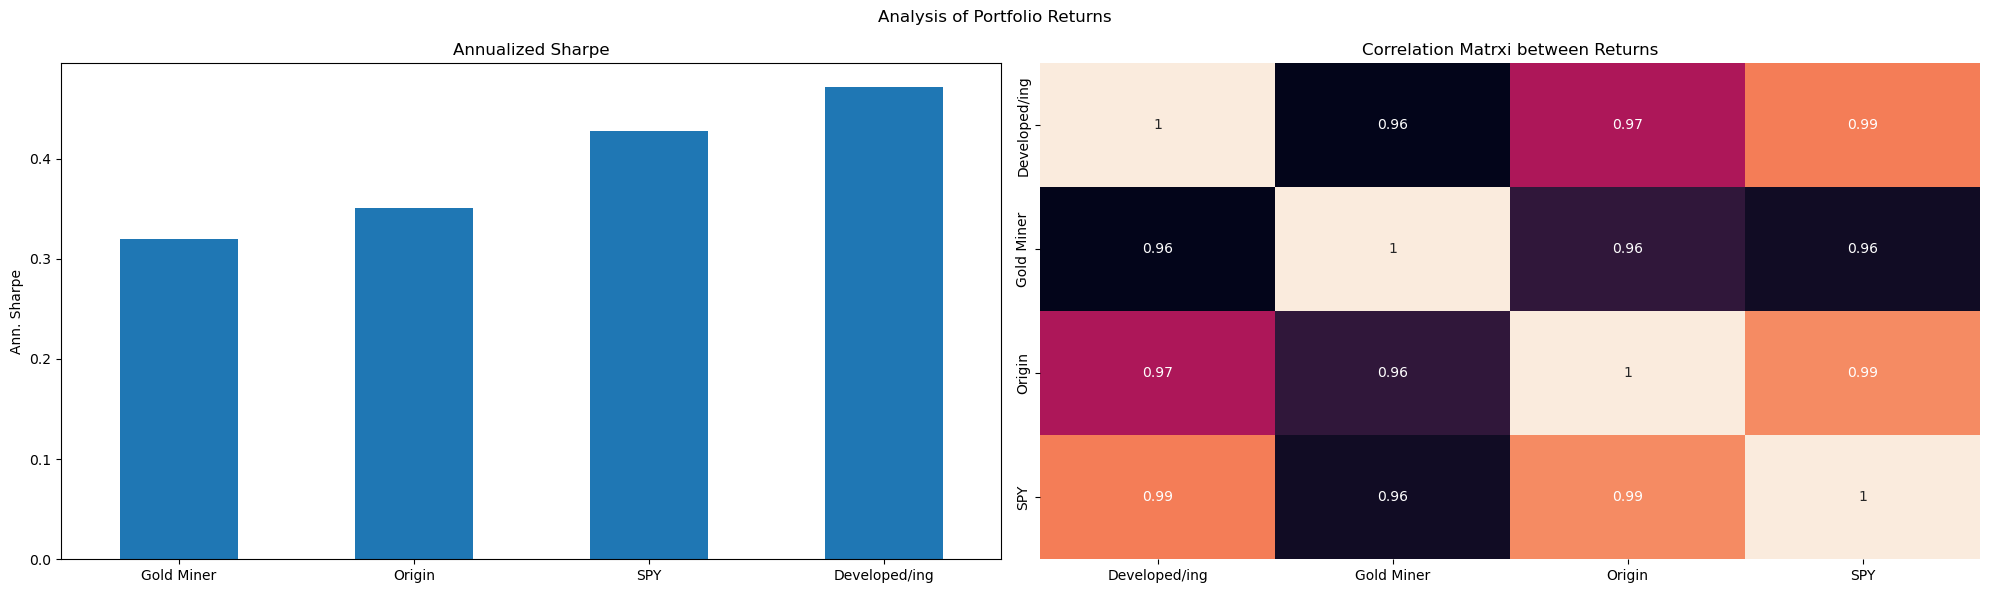

In [9]:
fig, axes = plt.subplots(ncols = 2, figsize = (20,6))

(df_port.drop(
    columns = ["date"]).
    groupby("group").
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    replace(replacer).
    set_index("group").
    sort_values("rtn").
    plot(
        ax     = axes[0],
        kind   = "bar",
        rot    = 0,
        xlabel = "",
        ylabel = "Ann. Sharpe",
        title  = "Annualized Sharpe",
        legend = False))

(sns.heatmap(
    data  = df_corr,
    ax    = axes[1],
    cbar  = False,
    annot = True))

axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].set_title("Correlation Matrxi between Returns")
fig.suptitle("Analysis of Portfolio Returns")
plt.tight_layout()

# Trading Deciles of Residuals

In [10]:
df_decile_sharpe = (df_ols[
    ["group_var", "decile", "gc_rtn"]].
    dropna().
    groupby(["group_var", "decile"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {"gc_rtn": "sharpe"}))

In [11]:
df_tmp = (df_decile_sharpe.query(
    "decile == [1,2,9,10]").
    assign(group = lambda x: np.where(x.decile <= 2, "lgroup", "ugroup")))

In [12]:
df_scaler = (df_tmp.drop(
    columns = ["decile"]).
    groupby(["group_var", "group"]).
    agg("prod").
    assign(signal_scaler = lambda x: np.where(x.sharpe > 0, 1, 0)).
    drop(columns = ["sharpe"]).
    reset_index())

In [13]:
df_decile_rtn = (df_tmp.merge(
    right = df_scaler, how = "inner", on = ["group_var", "group"]).
    drop(columns = ["group"]).
    assign(signal = lambda x: np.sign(x.sharpe) * x.signal_scaler).
    merge(right = df_ols, how = "outer", on = ["group_var", "decile"]).
    assign(signal_rtn = lambda x: x.signal * x.gc_rtn))

In [14]:
df_decile_rsk_rtn = (df_decile_rtn.pivot(
    index = "date", columns = "group_var", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.1, np.nan, x)).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(
        ticker = lambda x: x.group_var.str.split(" ").str[0],
        group  = lambda x: x.group_var.str.split(" ").str[1]))

In [15]:
replacer = {
    "country": "Origin",
    "country_type_group": "Developed/ing",
    "gdx"               : "Gold Miner",
    "spy"               : "SPY"}

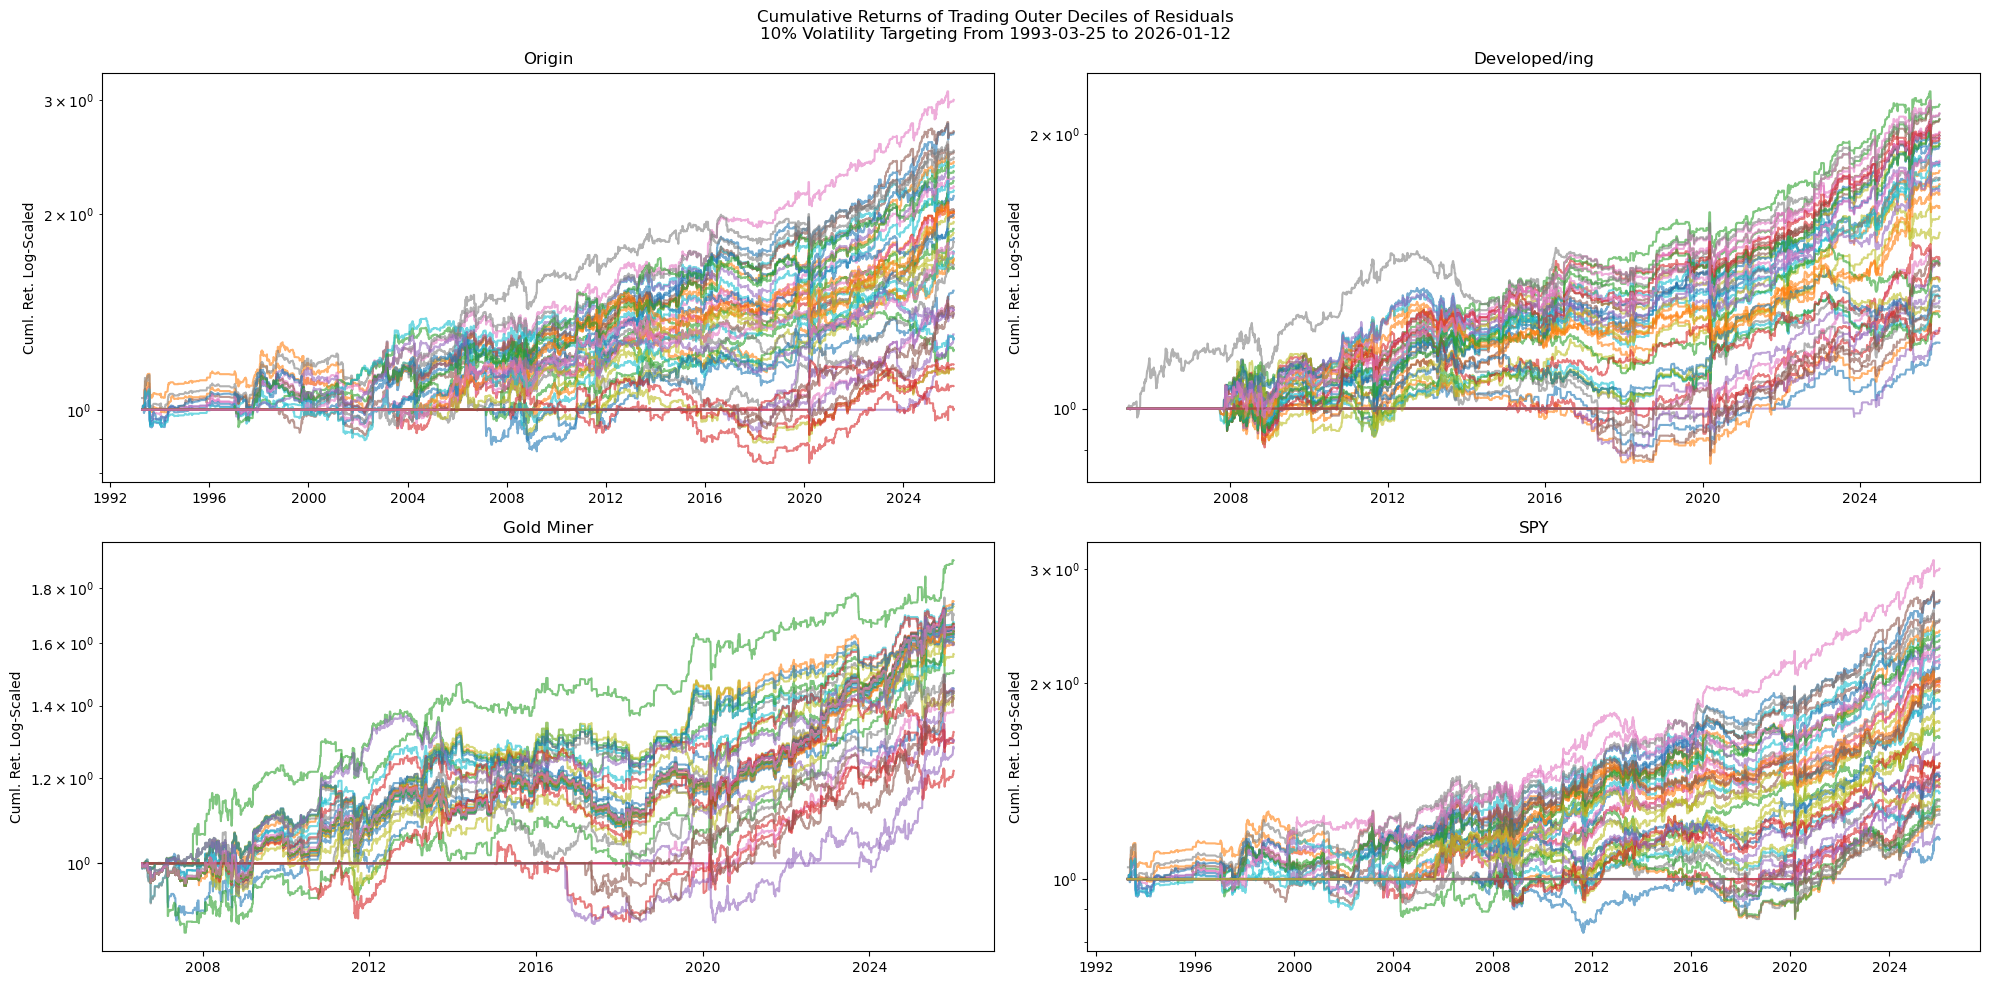

In [16]:
groups    = df_decile_rsk_rtn.group.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(groups) // 2, nrows = len(groups) // 2, figsize = (20,10))

for group, ax in zip(groups, axes.flatten()): 

    (df_decile_rsk_rtn.query(
        "group == @group").
        dropna().
        pivot(index = "date", columns = "ticker", values = "rtn").
        fillna(0).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            logy   = True, 
            alpha  = 0.6, 
            legend = False,
            xlabel = "",
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = replacer[group]))

fig.suptitle("Cumulative Returns of Trading Outer Deciles of Residuals\n10% Volatility Targeting From {} to {}".format(
    df_decile_rsk_rtn.date.min(),
    df_decile_rsk_rtn.date.max()))

plt.tight_layout()

In [17]:
df_decile_port = (df_decile_rsk_rtn.drop(
    columns = ["group_var", "ticker"]).
    dropna().
    groupby(["date", "group"]).
    agg("mean").
    reset_index())

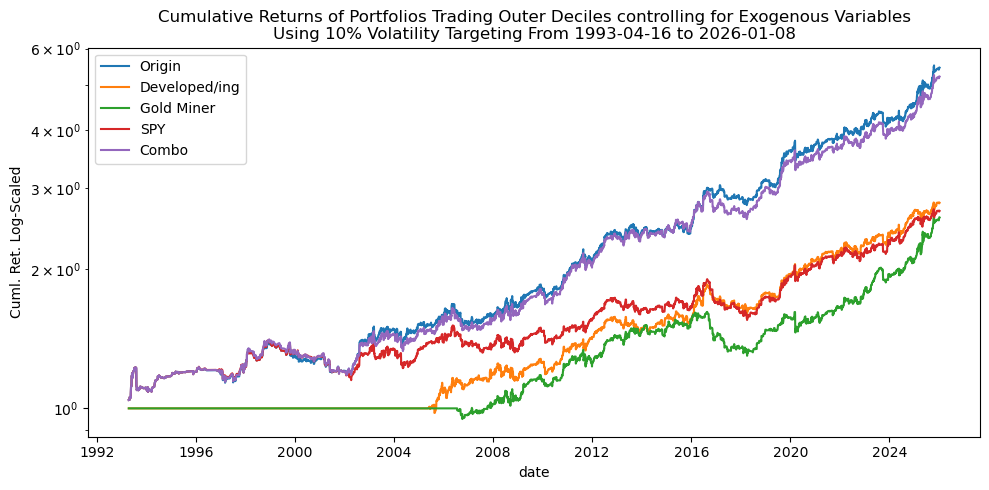

In [18]:
df_port_wider = (df_decile_port.rename(
    columns = {"group": ""}).
    pivot(index = "date", columns = "", values = "rtn").
    assign(Combo = lambda x: x.mean(axis = 1)))
    
(df_port_wider.rename(
    columns = replacer).
    fillna(0).
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        figsize = (10,5),
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Cumulative Returns of Portfolios Trading Outer Deciles controlling for Exogenous Variables\nUsing 10% Volatility Targeting From {} to {}".format(
            df_decile_port.date.min(),
            df_decile_port.date.max())))

plt.tight_layout()

In [19]:
(df_port_wider.rename(
    columns = replacer).
    reset_index().
    melt(id_vars = "date", var_name = "group", value_name = "raw_val").
    assign(adj_val = lambda x: np.where(x.raw_val == 0, np.nan, x.raw_val)).
    melt(id_vars = ["date", "group"]).
    dropna().
    drop(columns = ["date"]).
    groupby(["group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {"variable": ""}).
    pivot(index = "group", columns = "", values = "value").
    rename(columns = {
        "adj_val": "Adj Sharpe",
        "raw_val": "Raw Sharpe"}).
    apply(lambda x: np.round(x,3)))

,Adj Sharpe,Raw Sharpe
group,,
Combo,0.989,0.969
Developed/ing,1.131,1.108
Gold Miner,1.033,0.996
Origin,1.050,1.023
SPY,0.741,0.725


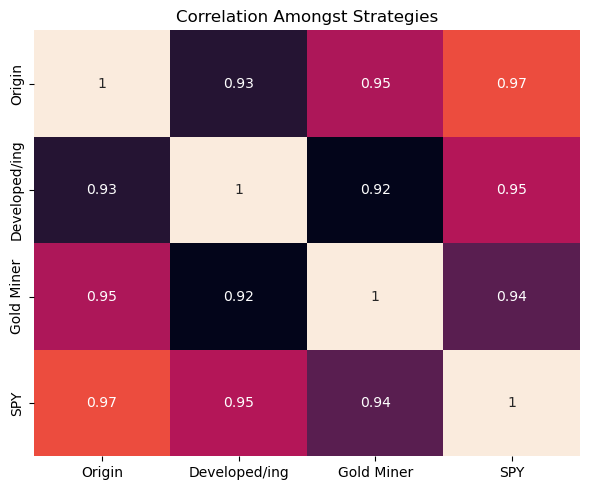

In [22]:
df_corr = (df_port_wider.drop(
    columns = ["Combo"]).
    rename(columns = replacer).
    corr())

fig, axes = plt.subplots(figsize = (6,5))

sns.heatmap(
    ax   = axes,
    data = df_corr,
    annot = True,
    cbar  = False)

axes.set_title("Correlation Amongst Strategies")
plt.tight_layout()